# Figure 3b (part 2): Polar Front position

Plots the latitudinal position of the Polar Front. Using the
definitions of Orsi et al. (1995), the front is the poleward location
of the 2C (275.15 K) isotherm of the temperature minimum between 0 and
200 m.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

The Polar Front is the southern counterpart of the Subantarctic Front
and marks the poleward edge of the Antarctic Circumpolar Current.

Following Orsi et al. (1995), it is identified by the 2C isotherm of the
subsurface temperature minimum between the surface and 200 m. That
minimum is the remnant of the previous winter's mixed layer, preserved
beneath the summer-warmed surface, so this definition follows a more
persistent feature than surface temperature alone.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
import iris


_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_DASHES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*"]


def style_for(index):
    """Line and marker style for the index-th dataset."""
    return {
        "color": _COLORS[index % len(_COLORS)],
        "dash": _DASHES[index % len(_DASHES)],
        "thick": 1.5,
        "mark": _MARKERS[index % len(_MARKERS)],
    }


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def closest_index(value, array):
    """Index of the array element closest to value (NCL closest_val)."""
    array = np.asarray(array, dtype=float)
    return int(np.nanargmin(np.abs(array - value)))


def time_mean(cube):
    """Average over the time dimension, if there is one."""
    if any(c.name() == "time" for c in cube.coords()):
        if cube.coord("time").shape[0] > 1:
            return cube.collapsed("time", iris.analysis.MEAN)
    return cube


def to_kelvin(data):
    """Make sure temperatures are in Kelvin, as the NCL scripts do.

    Values of exactly 0 are masked when the field is already in Kelvin
    (some models use 0 as a fill value).
    """
    data = np.ma.masked_invalid(data)
    if data.max() > 273.0:
        return np.ma.masked_values(data, 0.0) if data.min() == 0 else data
    return data + 273.0


def extract_isoline(lon2d, lat2d, field, level):
    """(lon, lat) points of an isoline of a 2D field.

    Replaces the NCL get_isolines call: contour the field against its
    lat/lon coordinates, take the longest contour segment as the main
    front and append further segments whose start is within 20 degrees
    longitude of the current end (stray points are discarded).
    """
    fig = plt.figure()
    try:
        contours = plt.contour(lon2d, lat2d,
                               np.ma.masked_invalid(field), [level])
        segments = [seg for seg in contours.allsegs[0] if len(seg) > 1]
    finally:
        plt.close(fig)
    if not segments:
        raise ValueError(f"No isoline found at level {level}")
    segments.sort(key=len, reverse=True)
    x = list(segments[0][:, 0])
    y = list(segments[0][:, 1])
    for seg in segments[1:]:
        if abs(seg[0, 0] - x[-1]) < 20.0:
            x.extend(seg[:, 0])
            y.extend(seg[:, 1])
    x, y = np.asarray(x), np.asarray(y)
    if x[min(11, len(x) - 1)] < x[min(1, len(x) - 1)]:
        x, y = x[::-1], y[::-1]
    return x, y


def replicate_isoline(x, y):
    """Repeat the isoline three times to span -360..360 degrees."""
    return (np.concatenate([x - 360.0, x, x + 360.0]),
            np.concatenate([y, y, y]))

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43919 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/43919/status,
Dashboard: /proxy/43919/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39965,Workers: 0
Dashboard: /proxy/43919/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46795,Total threads: 2
Dashboard: /proxy/38969/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:46525,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

thetao_datasets = {
    "CanESM2": Dataset(
        short_name="thetao",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "CSIRO-Mk3-6-0": Dataset(
        short_name="thetao",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CSIRO-Mk3-6-0",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2M": Dataset(
        short_name="thetao",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2M",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

This diagnostic works on the raw data (no preprocessor is applied), so
the cubes are only loaded here.  The time average is taken as part of
the diagnostic.

In [5]:
def preprocess(cube):
    """No preprocessing is applied for this figure."""
    return cube


thetao_cubes = {name: preprocess(dataset.load()) for name, dataset in thetao_datasets.items()}

thetao_cubes

{'CanESM2': <iris 'Cube' of sea_water_potential_temperature / (K) (time: 240; depth: 40; latitude: 192; longitude: 256)>,
 'CSIRO-Mk3-6-0': <iris 'Cube' of sea_water_potential_temperature / (K) (time: 240; depth: 31; latitude: 189; longitude: 192)>,
 'GFDL-ESM2M': <iris 'Cube' of sea_water_potential_temperature / (K) (time: 240; depth: 50; grid_latitude: 200; grid_longitude: 360)>}

## Diagnostic

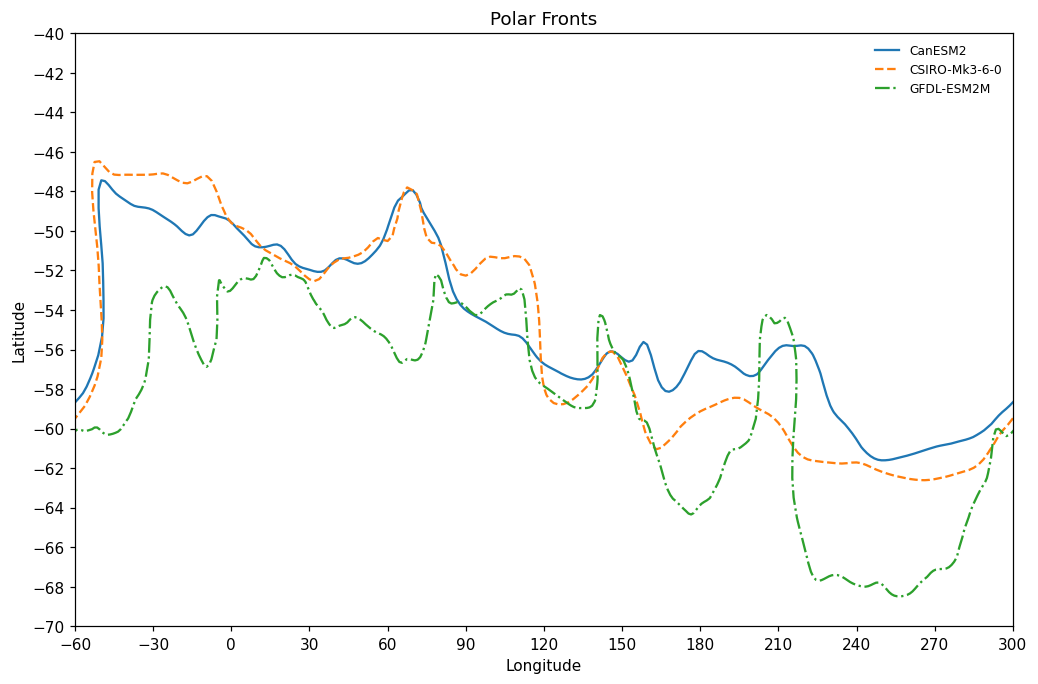

Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/locks.py", line 212, in wait
    await fut
asyncio.exceptions.CancelledError

During handling of th

In [6]:
ISOTHERM = 275.15   # 2 degrees Celsius in Kelvin
LAT_RANGE = (-80.0, -40.0)

fig, ax = plt.subplots(figsize=(11, 7))

for i, (name, cube) in enumerate(thetao_cubes.items()):
    mean = time_mean(cube)
    data = to_kelvin(mean.data)
    depth = mean.coord(axis="Z").points

    # temperature minimum between the surface and 200 m
    idx = closest_index(200.0, depth)
    if depth[idx] >= 200.0:
        idx -= 1
    field = data[:idx + 1].min(axis=0)

    lat = coord_1d_or_2d(mean, "latitude")
    lon = coord_1d_or_2d(mean, "longitude")
    if lat.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
    else:
        lat2d, lon2d = lat, lon

    # restrict to the Southern Ocean band and sort by longitude
    rows = ((lat2d[:, 0] >= LAT_RANGE[0]) & (lat2d[:, 0] <= LAT_RANGE[1]))
    order = np.argsort(lon2d[0, :])

    x, y = extract_isoline(lon2d[rows][:, order], lat2d[rows][:, order],
                           field[rows][:, order], ISOTHERM)
    x, y = replicate_isoline(x, y)      # repeat over -360..360

    style = style_for(i)
    ax.plot(x, y, label=name, color=style["color"],
            linestyle=style["dash"], linewidth=style["thick"])

ax.set_xlim(-60, 300)
ax.set_ylim(-70, -40)
ax.set_xticks(np.arange(-60, 301, 30))
ax.set_yticks(np.arange(-70, -39, 2))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Polar Fronts")
ax.legend(fontsize=8, frameon=False)
plt.show()

**Figure 3b (part 2): Polar Front position:** Latitudinal position of the Polar Front, defined as the poleward location
of the 2C isotherm of the 0-200 m temperature minimum.